# daf q

In [1]:
from pathlib import Path
import numpy as np
import imageio.v3 as iio
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tqdm.notebook import tqdm
from skimage.color import rgb2gray
from skimage.registration import optical_flow_tvl1
from matplotlib.colors import hsv_to_rgb
from scipy.ndimage import gaussian_filter


def resize_keep_aspect(frame, target_width=300):
    h, w = frame.shape[:2]
    scale = target_width / w
    new_h = int(round(h * scale))

    return cv2.resize(
        frame,
        (target_width, new_h),
        interpolation=cv2.INTER_AREA,
    )


def frame_to_gray(frame):
    frame = np.asarray(frame)

    if frame.ndim == 2:
        gray = frame
    elif frame.ndim == 3:
        if frame.shape[2] == 4:
            frame = frame[..., :3]
        gray = rgb2gray(frame)
    else:
        raise ValueError(f"Unsupported frame shape: {frame.shape}")

    gray = gray.astype(np.float32)

    if gray.max() > 1:
        gray /= 255.0

    return gray


def flow_to_rgb(flow_y, flow_x, max_magnitude=None):
    mag = np.sqrt(flow_x**2 + flow_y**2)
    ang = np.arctan2(flow_y, flow_x)

    if max_magnitude is None:
        max_magnitude = np.nanpercentile(mag, 99)

    if not np.isfinite(max_magnitude) or max_magnitude <= 0:
        max_magnitude = 1.0

    norm = np.clip(mag / max_magnitude, 0, 1)

    hsv = np.zeros((*flow_y.shape, 3), dtype=np.float32)
    hsv[..., 0] = (ang + np.pi) / (2 * np.pi)
    hsv[..., 1] = norm
    hsv[..., 2] = norm

    return (hsv_to_rgb(hsv) * 255).astype(np.uint8)


def preview_flow_frame(
    frame,
    velocity_frame,
    growth_map=None,
    flow_x=None,
    flow_y=None,
    frame_idx=None,
):
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))

    ax[0].imshow(frame, cmap="gray")
    ax[0].set_title("Downsampled input")

    ax[1].imshow(velocity_frame)
    ax[1].set_title("Optic flow")

    if growth_map is not None:
        #vmax = np.nanpercentile(growth_map, 99)
        #if not np.isfinite(vmax) or vmax <= 0:
        #    vmax = 1.0

        ax[2].imshow(growth_map, cmap="jet", vmin=0, vmax=.1)
        ax[2].set_title("Flow derivative energy")
    else:
        ax[2].axis("off")

    if flow_x is not None and flow_y is not None:
        step = max(1, frame.shape[1] // 30)

        yy, xx = np.mgrid[
            step // 2:frame.shape[0]:step,
            step // 2:frame.shape[1]:step,
        ]

        ax[1].quiver(
            xx,
            yy,
            flow_x[yy, xx],
            flow_y[yy, xx],
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.002,
        )

    for a in ax:
        a.axis("off")

    if frame_idx is not None:
        fig.suptitle(f"Frame {frame_idx}")

    clear_output(wait=True)
    display(fig)
    plt.close(fig)

def flow_derivative_energy(flow_y, flow_x):
    """
    One-channel map of local spatial change in the flow field.
    High values = flow changes/grows/shears locally.
    """
    dfx_dy, dfx_dx = np.gradient(flow_x)
    dfy_dy, dfy_dx = np.gradient(flow_y)

    energy = ( dfx_dx**2 + dfx_dy**2 + dfy_dx**2 + dfy_dy**2 )
    energy = dfx_dx + dfy_dy #divergence

    return energy

def convert_video_to_velocity(
    input_path,
    output_path,
    fps=30,
    target_width=300,
    max_frames=None,
    preview_every=20,
    show_quiver=True,
):
    input_path = Path(input_path)
    output_path = Path(output_path)

    reader = iio.imiter(input_path, plugin="pyav")

    first_frame = next(reader)
    first_small = resize_keep_aspect(first_frame, target_width=target_width)
    prev_gray = frame_to_gray(first_small)

    out_h, out_w = prev_gray.shape

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        fps,
        (out_w, out_h),
        isColor=True,
    )

    if not writer.isOpened():
        raise RuntimeError(f"Could not open video writer: {output_path}")

    try:
        for i, frame in enumerate(tqdm(reader, desc="Computing optic flow")):
            if max_frames is not None and i >= max_frames:
                break

            small = resize_keep_aspect(frame, target_width=target_width)
            gray = frame_to_gray(small)

            flow_y, flow_x = optical_flow_tvl1(
                prev_gray,
                gray,
                attachment=5.0,
                num_warp=4,
                num_iter=5,
                prefilter=True,
            )
            
            flow_y = gaussian_filter(flow_y, sigma=3)
            flow_x = gaussian_filter(flow_x, sigma=3)

            velocity_frame_rgb = flow_to_rgb(flow_y, flow_x)

            # OpenCV expects BGR, not RGB
            velocity_frame_bgr = cv2.cvtColor(
                velocity_frame_rgb,
                cv2.COLOR_RGB2BGR,
            )

            writer.write(velocity_frame_bgr)
            
            growth_map = flow_derivative_energy(flow_y, flow_x)

            if preview_every is not None and i % preview_every == 0:
                preview_flow_frame(
                    gray,
                    velocity_frame_rgb,
                    growth_map=growth_map,
                    flow_x=flow_x if show_quiver else None,
                    flow_y=flow_y if show_quiver else None,
                    frame_idx=i,
                )

            prev_gray = gray

    finally:
        writer.release()

    print(f"Saved: {output_path}")

In [2]:
# --- Execution ---
temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'


videopath = Path(temppath) / 'zebra_s0_d420.0_fps59.94_RESAMPLED30fps.mp4'
#videopath = Path(temppath) / 'zebra_s0_d420.0_fps59.94.mp4'

outpath= Path(temppath) / 'output_velocity.mp4'

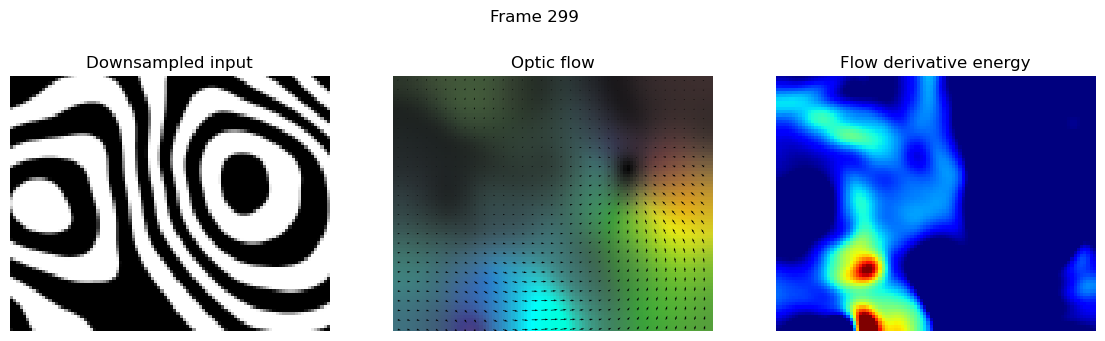

Saved: D:\SynologyDriveSyncedDATA\PROCESSED\Waven\output_velocity.mp4


In [3]:
convert_video_to_velocity(
    videopath,
    outpath,
    fps=30,
    target_width=100,
    max_frames=300,
    preview_every=1,
)

In [7]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from tqdm.notebook import tqdm
from scipy.ndimage import gaussian_filter


def load_resized_gray_frames(videopath, target_width=100, max_frames=300):
    frames = []

    reader = iio.imiter(videopath, plugin="pyav")

    for i, frame in enumerate(tqdm(reader, desc="Loading resized frames")):
        if i > max_frames:
            break

        small = resize_keep_aspect(frame, target_width=target_width)
        gray = frame_to_gray(small)
        frames.append(gray)

    return frames


gray_frames = load_resized_gray_frames(
    videopath,
    target_width=100,
    max_frames=300,
)


def inspect_flow_frame(
    frame_idx,
    smooth_sigma=3,
    show_quiver=True,
):
    if frame_idx < 1:
        frame_idx = 1

    prev_gray = gray_frames[frame_idx - 1]
    gray = gray_frames[frame_idx]

    flow_y, flow_x = optical_flow_tvl1(
        prev_gray,
        gray,
        attachment=5.0,
        num_warp=4,
        num_iter=5,
        prefilter=True,
    )

    flow_y = gaussian_filter(flow_y, sigma=smooth_sigma)
    flow_x = gaussian_filter(flow_x, sigma=smooth_sigma)

    velocity_frame_rgb = flow_to_rgb(flow_y, flow_x, max_magnitude=3)
    growth_map = flow_derivative_energy(flow_y, flow_x)

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))

    ax[0].imshow(2*gray+prev_gray, cmap="jet")
    ax[0].set_title(f"Input frame {frame_idx}")

    ax[1].imshow(velocity_frame_rgb)
    ax[1].set_title(f"Optic flow")# x+{np.max(flow_x):.2f}, x{np.min(flow_x):.2f}, y+{np.max(flow_y):.2f}, y{np.min(flow_y):.2f}")

    if show_quiver:
        step = max(1, gray.shape[1] // 30)

        yy, xx = np.mgrid[
            step // 2:gray.shape[0]:step,
            step // 2:gray.shape[1]:step,
        ]

        ax[1].quiver(
            xx,
            yy,
            flow_x[yy, xx],
            flow_y[yy, xx],
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.002,
        )

    vmax = np.nanpercentile(growth_map, 99)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0

    ax[2].imshow(growth_map, cmap="jet", vmin=-0.50, vmax=0.5)
    ax[2].set_title("Flow derivative energy")

    for a in ax:
        a.axis("off")

    plt.show()


widgets.interact(
    inspect_flow_frame,
    frame_idx=widgets.IntSlider(
        value=1,
        min=1,
        max=len(gray_frames) - 1,
        step=1,
        description="Frame",
        continuous_update=False,
    ),
    smooth_sigma=widgets.FloatSlider(
        value=3,
        min=0,
        max=10,
        step=0.5,
        description="Smooth σ",
        continuous_update=False,
    ),
    show_quiver=widgets.Checkbox(
        value=True,
        description="Quiver",
    ),
)

Loading resized frames: 0it [00:00, ?it/s]

interactive(children=(IntSlider(value=1, continuous_update=False, description='Frame', max=300, min=1), FloatS…

<function __main__.inspect_flow_frame(frame_idx, smooth_sigma=3, show_quiver=True)>